# 15 — Three-Domain Aggregation (WNUT-17 + SciERC + JNLPBA)

Unifies the two arms that were run on **all three** target domains — few-shot fine-tuning
(Arm 1) and LLM prompting (Arm 3) — into a single three-panel data-efficiency figure, a per-type
breakdown per domain, and an LLM-minus-fine-tuning gap table that surfaces the crossover.

It **reads** results only (WNUT/SciERC from `results/fewshot/` + `results/llm_prompting/`, JNLPBA
from `results/jnlpba/`) and writes new figures/CSVs under `results/three_domain/`. Nothing that
notebooks 04–10 produced is modified. (DAP/mitigation exist only for WNUT/SciERC and are covered
by Notebook 10; this notebook focuses on the two arms common to all three domains.)

In [1]:
!pip -q install pandas matplotlib seaborn

In [2]:
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

import json
from pathlib import Path
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style='whitegrid')

PROCESSED = Path('/content/drive/MyDrive/AAI590/data/processed')
R = PROCESSED / 'results'
JN = R / 'jnlpba'
OUT_DIR = R / 'three_domain'; OUT_DIR.mkdir(parents=True, exist_ok=True)
BUDGETS = [50, 100, 200]
DOMAINS = ['wnut17', 'scierc', 'jnlpba']

def pick(df, cols):
    df = df.copy()
    for c in cols:
        if c not in df.columns: df[c] = None
    return df[cols]

# ---- Few-shot fine-tuning (Arm 1) across all three domains ----
ft_parts = []
ff = R / 'fewshot' / 'fewshot_results.csv'
if ff.exists():
    ft_parts.append(pick(pd.read_csv(ff), ['dataset','budget','seed','test_typed_f1','per_type']))
if (JN / 'fewshot_jnlpba.csv').exists():
    ft_parts.append(pick(pd.read_csv(JN / 'fewshot_jnlpba.csv'), ['dataset','budget','seed','test_typed_f1','per_type']))
ft = pd.concat(ft_parts, ignore_index=True); ft['method'] = 'Few-shot FT (Arm 1)'

# ---- LLM prompting (Arm 3) across all three domains ----
llm_parts = []
lf = R / 'llm_prompting' / 'llm_prompting_results.csv'
if lf.exists():
    llm_parts.append(pick(pd.read_csv(lf), ['dataset','budget','seed','test_typed_f1','per_type']))
if (JN / 'llm_jnlpba.csv').exists():
    llm_parts.append(pick(pd.read_csv(JN / 'llm_jnlpba.csv'), ['dataset','budget','seed','test_typed_f1','per_type']))
llm = pd.concat(llm_parts, ignore_index=True); llm['method'] = 'LLM prompting (Arm 3)'
llm = llm[llm['budget'].isin(BUDGETS)]   # drop zero-shot (budget 0) from the budget curve

combined = pd.concat([ft, llm], ignore_index=True)
combined = combined[combined['dataset'].isin(DOMAINS)]
combined.drop(columns=['per_type']).to_csv(OUT_DIR / 'three_domain_combined.csv', index=False)
print('rows per (dataset, method):')
print(combined.groupby(['dataset','method']).size())

Mounted at /content/drive
rows per (dataset, method):
dataset  method               
jnlpba   Few-shot FT (Arm 1)      9
         LLM prompting (Arm 3)    3
scierc   Few-shot FT (Arm 1)      9
         LLM prompting (Arm 3)    3
wnut17   Few-shot FT (Arm 1)      9
         LLM prompting (Arm 3)    3
dtype: int64


## Data-efficiency across all three domains (typed F1)

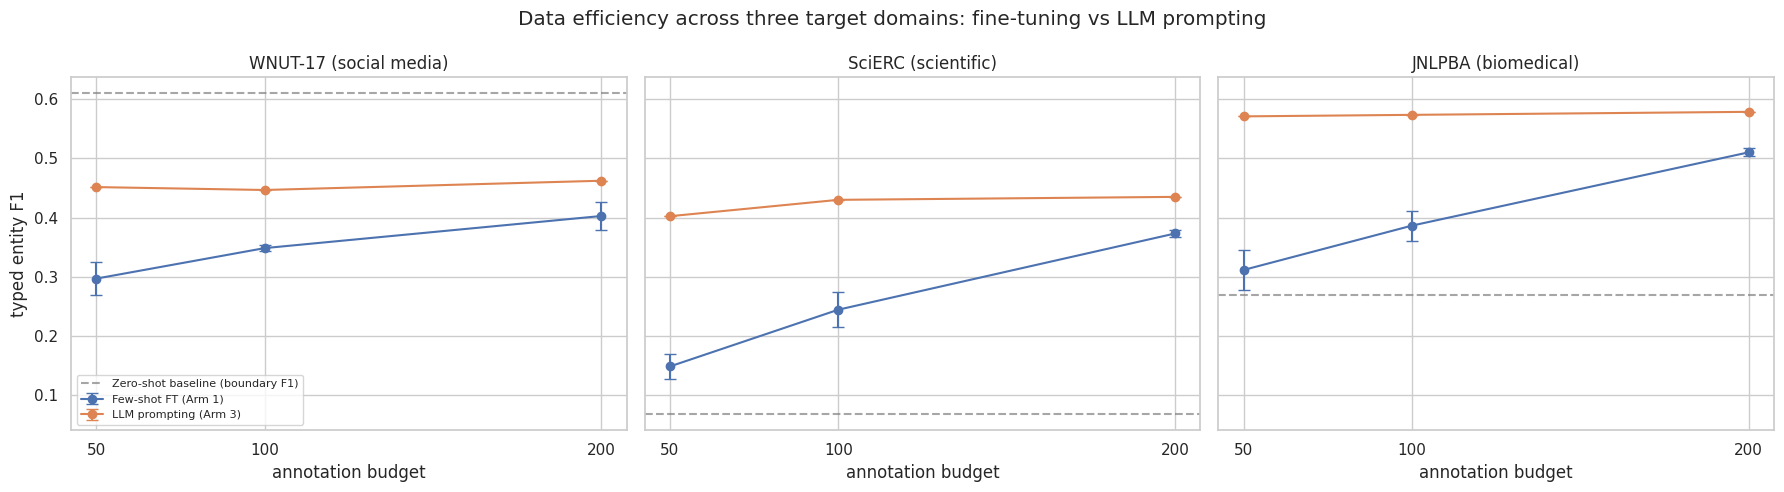

method          Few-shot FT (Arm 1)  LLM prompting (Arm 3)
dataset budget                                            
jnlpba  50                    0.312                  0.571
        100                   0.387                  0.573
        200                   0.510                  0.578
scierc  50                    0.149                  0.402
        100                   0.245                  0.430
        200                   0.373                  0.435
wnut17  50                    0.297                  0.451
        100                   0.349                  0.447
        200                   0.403                  0.462

In [3]:
# zero-shot boundary references
zs = {}
bj = R / 'baseline_results.json'
if bj.exists():
    for d, m in json.load(open(bj)).get('zero_shot_cross_domain_boundary_f1', {}).items(): zs[d] = m['f1']
bjn = JN / 'baseline_jnlpba.json'
if bjn.exists():
    for d, m in json.load(open(bjn)).get('zero_shot_cross_domain_boundary_f1', {}).items(): zs[d] = m['f1']

agg = (combined.groupby(['dataset','method','budget'], as_index=False)
       .agg(f1_mean=('test_typed_f1','mean'), f1_std=('test_typed_f1','std')))
agg['f1_std'] = agg['f1_std'].fillna(0.0)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
titles = {'wnut17':'WNUT-17 (social media)', 'scierc':'SciERC (scientific)', 'jnlpba':'JNLPBA (biomedical)'}
for ax, d in zip(axes, DOMAINS):
    for method, sub in agg[agg['dataset']==d].groupby('method'):
        sub = sub.sort_values('budget')
        ax.errorbar(sub['budget'], sub['f1_mean'], yerr=sub['f1_std'], marker='o', capsize=4, label=method)
    if d in zs:
        ax.axhline(zs[d], ls='--', color='gray', alpha=0.7, label='Zero-shot baseline (boundary F1)')
    ax.set_title(titles[d]); ax.set_xlabel('annotation budget'); ax.set_xticks(BUDGETS)
axes[0].set_ylabel('typed entity F1'); axes[0].legend(fontsize=8)
fig.suptitle('Data efficiency across three target domains: fine-tuning vs LLM prompting')
fig.tight_layout(); fig.savefig(OUT_DIR / 'three_domain_data_efficiency.png', dpi=150, bbox_inches='tight')
plt.show()
display(agg.pivot_table(index=['dataset','budget'], columns='method', values='f1_mean').round(3))

## LLM − fine-tuning gap (the crossover view)

In [4]:
piv = agg.pivot_table(index=['dataset','budget'], columns='method', values='f1_mean').reset_index()
piv['llm_minus_ft'] = (piv['LLM prompting (Arm 3)'] - piv['Few-shot FT (Arm 1)']).round(3)
piv = piv.round(3)
piv.to_csv(OUT_DIR / 'three_domain_gap.csv', index=False)
display(piv)
print('\nThe LLM lead is largest at budget 50 and shrinks as labels grow, fastest on JNLPBA')
print('(the most learnable domain for fine-tuning) -- the data-efficiency crossover.')

method,dataset,budget,Few-shot FT (Arm 1),LLM prompting (Arm 3),llm_minus_ft
0,jnlpba,50,0.312,0.571,0.259
1,jnlpba,100,0.387,0.573,0.187
2,jnlpba,200,0.510,0.578,0.068
3,scierc,50,0.149,0.402,0.253
4,scierc,100,0.245,0.430,0.185
5,scierc,200,0.373,0.435,0.062
6,wnut17,50,0.297,0.451,0.154
7,wnut17,100,0.349,0.447,0.098
8,wnut17,200,0.403,0.462,0.059



The LLM lead is largest at budget 50 and shrinks as labels grow, fastest on JNLPBA
(the most learnable domain for fine-tuning) -- the data-efficiency crossover.


## Per-entity-type F1 at budget 200 (each domain)

In [5]:
rows = []
for _, r in combined[combined['budget']==200].iterrows():
    if not isinstance(r['per_type'], str): continue
    try: pt = json.loads(r['per_type'])
    except Exception: continue
    for et, m in pt.items():
        rows.append({'dataset': r['dataset'], 'method': r['method'], 'entity_type': et,
                     'f1': m['f1'], 'support': m['support']})
pt_df = pd.DataFrame(rows)
for d in DOMAINS:
    sub = pt_df[pt_df['dataset']==d]
    if sub.empty: continue
    tab = (sub.groupby(['entity_type','method'], as_index=False)
           .agg(f1=('f1','mean'))
           .pivot(index='entity_type', columns='method', values='f1').round(3))
    print(f'\n=== {d} -- per-type F1 @ budget 200 ==='); display(tab)
    tab.to_csv(OUT_DIR / f'per_type_{d}.csv')
print('\nsaved -> three_domain_data_efficiency.png, three_domain_gap.csv, three_domain_combined.csv, per_type_*.csv')


=== wnut17 -- per-type F1 @ budget 200 ===


method,Few-shot FT (Arm 1),LLM prompting (Arm 3)
entity_type,,
corporation,0.179,0.411
creative-work,0.256,0.446
group,0.259,0.248
location,0.407,0.573
person,0.621,0.556
product,0.044,0.277



=== scierc -- per-type F1 @ budget 200 ===


method,Few-shot FT (Arm 1),LLM prompting (Arm 3)
entity_type,,
Generic,0.559,0.318
Material,0.186,0.370
Method,0.477,0.551
Metric,0.009,0.412
OtherScientificTerm,0.324,0.405
Task,0.287,0.456



=== jnlpba -- per-type F1 @ budget 200 ===


method,Few-shot FT (Arm 1),LLM prompting (Arm 3)
entity_type,,
DNA,0.386,0.555
RNA,0.000,0.610
cell_line,0.220,0.478
cell_type,0.481,0.522
protein,0.581,0.615



saved -> three_domain_data_efficiency.png, three_domain_gap.csv, three_domain_combined.csv, per_type_*.csv
